In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"

df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")

Total catalog objects: 13,922,457


In [4]:
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")

Resolved galaxies: 154,638


In [5]:
resolved["M_star_Msun"] = (
    resolved["M_star"] * 1e10 / 0.6774
)


Generate resolved table

In [6]:
resolved["M_star_Msun"] = (
    resolved["M_star"] * 1e10 / 0.6774
)

mass_selected = resolved[
    (resolved["M_star_Msun"] > 1e9) &
    (resolved["M_star_Msun"] < 1e10)
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
print(f"After stellar-mass selection: {len(mass_selected):,}")

Resolved galaxies: 154,638
After stellar-mass selection: 57,625


In [7]:
satellites = mass_selected[
    mass_selected["IsSatellite"] == True
].copy()
satellites["Host_M200c_Msun"] = (
    satellites["Host_M200c"] * 1e10 / 0.6774
)

print(f"Satellite galaxies: {len(satellites):,}")

Satellite galaxies: 25,120


In [8]:
group_selected = satellites[
    satellites["Host_M200c_Msun"] > 1e13
].copy()

print(f"Satellite galaxies in massive hosts: {len(group_selected):,}")

Satellite galaxies in massive hosts: 15,595


In [9]:
dmdgs = group_selected[
    group_selected["f_DM"] < 0.5
].copy()

In [10]:
print("=== DMDG SELECTION PIPELINE ===")
print(f"Full TNG300-1 catalog:              {len(df):,}")
print(f"Resolved galaxies:                  {len(resolved):,}")
print(f"10^9 < M* < 10^10 Msun:             {len(mass_selected):,}")
print(f"Satellite galaxies:                 {len(satellites):,}")
print(f"Host M200c > 10^13 Msun:             {len(group_selected):,}")
print(f"DMDGs (f_DM < 0.5):                  {len(dmdgs):,}")

=== DMDG SELECTION PIPELINE ===
Full TNG300-1 catalog:              13,922,457
Resolved galaxies:                  154,638
10^9 < M* < 10^10 Msun:             57,625
Satellite galaxies:                 25,120
Host M200c > 10^13 Msun:             15,595
DMDGs (f_DM < 0.5):                  513


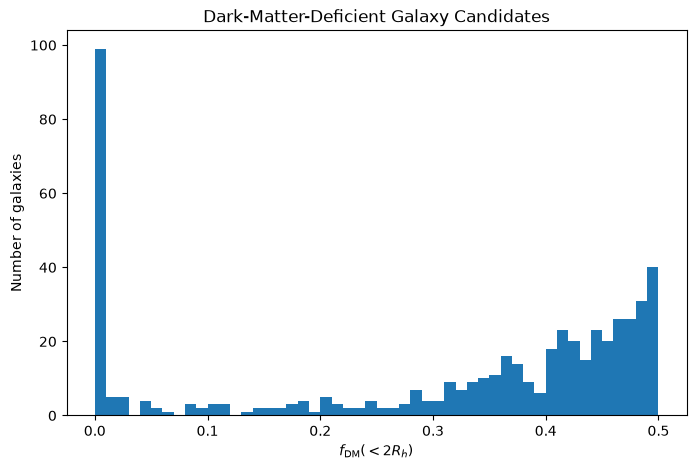

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(dmdgs["f_DM"], bins=50)
plt.xlabel(r"$f_{\rm DM}(<2R_h)$")
plt.ylabel("Number of galaxies")
plt.title("Dark-Matter-Deficient Galaxy Candidates")
plt.show()

In [12]:
print(dmdgs["f_DM"].quantile([
    0,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.0
]))

0.00    0.000000
0.01    0.000000
0.05    0.000000
0.10    0.000000
0.25    0.143268
0.50    0.380614
0.75    0.456590
0.90    0.486979
0.95    0.493586
0.99    0.498928
1.00    0.499990
Name: f_DM, dtype: float64


In [14]:
dmdg_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"Non-Extreme DMDGS: {len(dmdg_non_extreme):,}")
print (f"Non-Extreme Fraction: {len(dmdg_non_extreme) / len(group_selected):,}")

Non-Extreme DMDGS: 400
Non-Extreme Fraction: 0.025649246553382493
